In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/student_scores.csv")
df

,study_hours,attendance,sleep_hours,exam_score
0,7,93,4,74
1,4,73,4,50
2,11,64,6,85
3,8,81,9,82
4,5,81,8,70
...,...,...,...,...
195,9,76,7,76
196,5,91,4,61
197,1,51,8,43
198,3,75,4,45


In [2]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   study_hours  200 non-null    int64
 1   attendance   200 non-null    int64
 2   sleep_hours  200 non-null    int64
 3   exam_score   200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


,study_hours,attendance,sleep_hours,exam_score
count,200.000000,200.00000,200.000000,200.000000
mean,7.010000,75.68000,6.460000,70.035000
std,3.488661,14.54598,1.686005,16.249121
min,1.000000,50.00000,4.000000,35.000000
25%,4.000000,65.75000,5.000000,58.000000
50%,7.000000,77.00000,7.000000,70.000000
75%,10.000000,86.25000,8.000000,83.000000
max,12.000000,100.00000,9.000000,100.000000


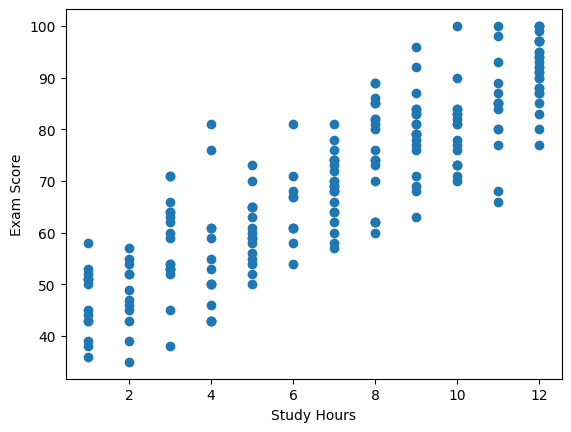

In [3]:
plt.scatter(df["study_hours"], df["exam_score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()


In [4]:
import sys
sys.path.append('..')

from sklearn.model_selection import train_test_split
from src.data_loader import load_data
from src.model import train_model
from src.evaluate import evaluate

In [6]:
data = load_data("../data/raw/student_scores.csv")

X = data[["study_hours", "attendance", "sleep_hours"]]
y = data["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = train_model(X_train, y_train)
mse = evaluate(model, X_test, y_test)

print("Mean Squared Error:", mse)


Mean Squared Error: 38.66310863700064


In [7]:
# Train vs test error
from sklearn.metrics import mean_squared_error

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)


Train MSE: 20.438568342142094
Test MSE: 38.66310863700064


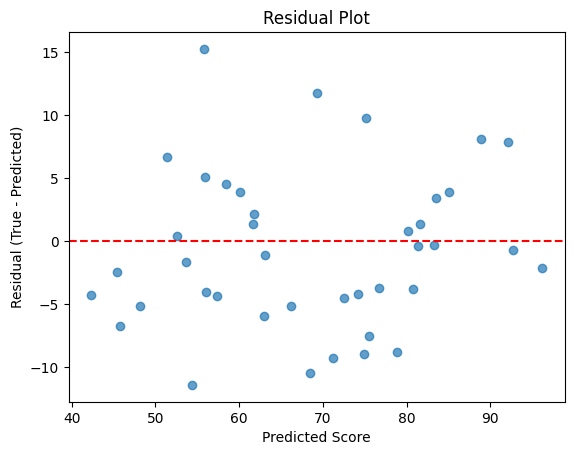

In [8]:
# Residual plot (y_true - y_pred) vs y_pred
import matplotlib.pyplot as plt

residuals = y_test - test_pred

plt.scatter(test_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Score")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residual Plot")
plt.show()


In [9]:
# Baseline: RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)

print("RandomForest Test MSE:", rf_mse)


RandomForest Test MSE: 45.8833797738166


In [10]:
# Light RandomForest tuning
from sklearn.model_selection import ParameterGrid

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

best_mse = float("inf")
best_params = None

for params in ParameterGrid(param_grid):
    rf_tuned = RandomForestRegressor(random_state=42, **params)
    rf_tuned.fit(X_train, y_train)
    pred = rf_tuned.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    if mse < best_mse:
        best_mse = mse
        best_params = params

print("Best RF MSE:", best_mse)
print("Best RF Params:", best_params)


Best RF MSE: 45.84041567806065
Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 500}


In [11]:
# Baseline: GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)
gbr_mse = mean_squared_error(y_test, gbr_pred)

print("GradientBoosting Test MSE:", gbr_mse)


GradientBoosting Test MSE: 47.812351718446976
